## Library import

In [1]:
# --- Standard library ---
from pathlib import Path
import warnings

# --- Core data science ---
import numpy as np
import pandas as pd

# --- Plotting ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Machine Learning ---
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, f1_score
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier

# --- Global config ---
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

## Dataset Load

In [2]:
# --- Path configuration ---
DATA_PATH = Path("../data/raw/enhanced_motor_vehicle_repair_towing_dataset.csv")
SAMPLE_ROWS = 1_000_000  # can be adjusted depending on computer memory availability
# --- Load sample ---
df = pd.read_csv(DATA_PATH, low_memory=False)

### Dataset overview

In [3]:
df.head(2)

,Service ID,Customer Name,Vehicle Type,Make and Model,Service Type,Service Description,Repair Date,Towing Date,Tow Location,Drop-off Location,Mechanic Name,Tow Truck Driver,Parts Used,Total Cost,Payment Method,Warranty Information,Service Status,Customer Feedback,Follow-up Needed,Urgency Level,Customer Type,Service Duration Hours,Estimated Cost,Mileage at Service,Insurance Claim Used,Technician Rating,Tow Distance Miles,Is Warranty Valid
0,100000,Emily Smith,Bus,BMW School Bus,Oil Change,Diagnosed and repaired Oil Drain Plug.,2022-05-14,NaN,NaN,NaN,Mechanic 2,NaN,"Oil Filter, Oil Drain Plug, Synthetic Oil",77.82,Cash,90 days on labor,In Progress,NaN,Yes,Scheduled,Fleet,3.6,70.5,114248,No,1.9,0.0,Yes
1,100001,David Smith,Truck,Harley-Davidson Ram 1500,Tire Replacement,Diagnosed and repaired Tire.,2020-07-08,NaN,NaN,NaN,Mechanic 13,NaN,"Rim, Tire, TPMS Sensor",135.97,Insurance,6 months on new tire,s,NaN,No,Emergency,Fleet,1.9,125.0,250870,Yes,4.9,0.0,Yes


In [ ]:
df.tail(2)

,Service ID,Customer Name,Vehicle Type,Make and Model,Service Type,Service Description,Repair Date,Towing Date,Tow Location,Drop-off Location,Mechanic Name,Tow Truck Driver,Parts Used,Total Cost,Payment Method,Warranty Information,Service Status,Customer Feedback,Follow-up Needed,Urgency Level,Customer Type,Service Duration Hours,Estimated Cost,Mileage at Service,Insurance Claim Used,Technician Rating,Tow Distance Miles,Is Warranty Valid
1999998,2099998,Emily Miller,Truck,Harley-Davidson F-150,Brake Service,Diagnosed and repaired Rotors.,2022-04-06,NaN,NaN,NaN,Mechanic 8,NaN,"Brake Fluid, Brake Pads, Calipers",162.11,Cash,180 days on brake pads,s,NaN,Yes,Standard,Individual,3.2,169.15,42408,No,1.6,0.0,Yes
1999999,2099999,Kimberly Johnson,Van,Yamaha Odyssey,Towing,Diagnosed and repaired no parts used.,2024-04-03,2021-11-25,Highway,Parking Lot,Mechanic 18,Driver 4,No parts used,107.45,Company Invoice,No warranty offered,s,NaN,No,Standard,Individual,2.3,110.62,97183,No,3.2,62.9,No


In [5]:
df.shape

(2000000, 28)

> This data has 2 million entries and 28 variables

In [6]:
df.columns.to_list()

['Service ID',
 'Customer Name',
 'Vehicle Type',
 'Make and Model',
 'Service Type',
 'Service Description',
 'Repair Date',
 'Towing Date',
 'Tow Location',
 'Drop-off Location',
 'Mechanic Name',
 'Tow Truck Driver',
 'Parts Used',
 'Total Cost',
 'Payment Method',
 'Warranty Information',
 'Service Status',
 'Customer Feedback',
 'Follow-up Needed',
 'Urgency Level',
 'Customer Type',
 'Service Duration Hours',
 'Estimated Cost',
 'Mileage at Service',
 'Insurance Claim Used',
 'Technician Rating',
 'Tow Distance Miles',
 'Is Warranty Valid']

### Standarize column names (snake_case)

In [7]:
df.columns = (df.columns
              .str.strip() # for espaces
              .str.lower() # lower case
              .str.replace(" ", "_") # insert _
              .str.replace("-", "_")) # replace - for _
df.columns.to_list()

['service_id',
 'customer_name',
 'vehicle_type',
 'make_and_model',
 'service_type',
 'service_description',
 'repair_date',
 'towing_date',
 'tow_location',
 'drop_off_location',
 'mechanic_name',
 'tow_truck_driver',
 'parts_used',
 'total_cost',
 'payment_method',
 'warranty_information',
 'service_status',
 'customer_feedback',
 'follow_up_needed',
 'urgency_level',
 'customer_type',
 'service_duration_hours',
 'estimated_cost',
 'mileage_at_service',
 'insurance_claim_used',
 'technician_rating',
 'tow_distance_miles',
 'is_warranty_valid']

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
service_id,2000000.0,1.100000e+06,577350.413527,100000.0,599999.75,1099999.50,1599999.25,2099999.00
total_cost,2000000.0,3.742204e+02,407.714041,20.0,104.90,198.77,478.95,2797.06
customer_feedback,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
service_duration_hours,2000000.0,3.028943e+00,1.437699,0.5,2.00,3.00,4.00,10.60
estimated_cost,2000000.0,3.742427e+02,409.037471,18.0,104.71,198.60,478.42,2913.37
mileage_at_service,2000000.0,1.549637e+05,83753.568480,10000.0,82359.00,154973.00,227471.00,300000.00
technician_rating,2000000.0,2.999025e+00,1.155602,1.0,2.00,3.00,4.00,5.00
tow_distance_miles,2000000.0,7.496640e+00,21.084843,0.0,0.00,0.00,0.00,100.00


> Notice that none of the clients has a feedback registered.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 28 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   service_id              int64  
 1   customer_name           object 
 2   vehicle_type            object 
 3   make_and_model          object 
 4   service_type            object 
 5   service_description     object 
 6   repair_date             object 
 7   towing_date             object 
 8   tow_location            object 
 9   drop_off_location       object 
 10  mechanic_name           object 
 11  tow_truck_driver        object 
 12  parts_used              object 
 13  total_cost              float64
 14  payment_method          object 
 15  warranty_information    object 
 16  service_status          object 
 17  customer_feedback       float64
 18  follow_up_needed        object 
 19  urgency_level           object 
 20  customer_type           object 
 21  service_duration_hours  float64

#### Missing Values

In [10]:
missing_percentage = df.isnull().sum() / df.shape[0] * 100
missing_percentage

service_id                  0.0000
customer_name               0.0000
vehicle_type                0.0000
make_and_model              0.0000
service_type                0.0000
service_description         0.0000
repair_date                 0.0000
towing_date                85.7131
tow_location               85.7131
drop_off_location          85.7131
mechanic_name               0.0000
tow_truck_driver           85.7131
parts_used                  0.0000
total_cost                  0.0000
payment_method              0.0000
warranty_information        0.0000
service_status              0.0000
customer_feedback         100.0000
follow_up_needed            0.0000
urgency_level               0.0000
customer_type               0.0000
service_duration_hours      0.0000
estimated_cost              0.0000
mileage_at_service          0.0000
insurance_claim_used        0.0000
technician_rating           0.0000
tow_distance_miles          0.0000
is_warranty_valid           0.0000
dtype: float64

In [12]:
counts = df['customer_name'].value_counts().reset_index()
counts.columns = ['Customer Name', 'Count']
counts

,Customer Name,Count
0,Sarah Smith,31641
1,James Johnson,31635
2,Laura Johnson,31622
3,Sarah Miller,31600
4,James Smith,31540
...,...,...
59,Michael Jones,31001
60,Michael Miller,30956
61,Sarah Davis,30927
62,Laura Miller,30851


In [13]:
df["vehicle_type"].value_counts()

vehicle_type
Van           334078
SUV           333522
Bus           333269
Truck         333230
Car           332956
Motorcycle    332945
Name: count, dtype: int64

In [14]:
df['make_and_model'].value_counts()

make_and_model
Toyota Coach             21083
Toyota School Bus        21067
Harley-Davidson Coach    21055
Yamaha Coach             20921
Yamaha School Bus        20890
                         ...  
Honda Civic               8215
Yamaha Camry              8174
Yamaha Civic              8168
Toyota Civic              8161
Chevrolet Corolla         8153
Name: count, Length: 176, dtype: int64

In [16]:
df["service_type"].value_counts(), df["service_type"].nunique()

(service_type
 Oil Change             286316
 Engine Repair          285929
 Battery Replacement    285923
 Tire Replacement       285837
 Towing                 285738
 Transmission Repair    285692
 Brake Service          284565
 Name: count, dtype: int64,
 7)

In [19]:
df['parts_used'].value_counts()

parts_used
No parts used                                   285738
Oil Filter, Synthetic Oil, Oil Drain Plug        48100
Gearbox Seal, Clutch Kit, Transmission Fluid     47942
Transmission Fluid, Clutch Kit, Gearbox Seal     47842
Battery, Battery Terminal, Battery Holder        47833
                                                 ...  
Timing Belt, Engine Mount, Oil Pump              11754
Rotors, Brake Pads, Calipers                     11745
Engine Mount, Timing Belt, Spark Plugs           11706
Calipers, Rotors, Brake Fluid                    11653
Brake Fluid, Calipers, Brake Pads                11621
Name: count, Length: 91, dtype: int64

In [20]:
df['parts_used'].unique().tolist()

['Oil Filter, Oil Drain Plug, Synthetic Oil',
 'Rim, Tire, TPMS Sensor',
 'Battery Terminal, Battery, Battery Holder',
 'Battery Holder, Battery, Battery Terminal',
 'No parts used',
 'Synthetic Oil, Oil Filter, Oil Drain Plug',
 'TPMS Sensor, Valve Stem, Rim',
 'Timing Belt, Oil Pump, Spark Plugs',
 'Gearbox Seal, Transmission Fluid, Clutch Kit',
 'Clutch Kit, Gearbox Seal, Transmission Fluid',
 'Synthetic Oil, Oil Drain Plug, Oil Filter',
 'Rim, TPMS Sensor, Valve Stem',
 'Tire, TPMS Sensor, Rim',
 'Clutch Kit, Transmission Fluid, Gearbox Seal',
 'Brake Pads, Calipers, Rotors',
 'Valve Stem, Tire, Rim',
 'Brake Fluid, Rotors, Calipers',
 'Rotors, Brake Fluid, Calipers',
 'Brake Pads, Brake Fluid, Rotors',
 'Calipers, Brake Pads, Rotors',
 'Transmission Fluid, Gearbox Seal, Clutch Kit',
 'TPMS Sensor, Rim, Tire',
 'Brake Fluid, Calipers, Rotors',
 'Battery Holder, Battery Terminal, Battery',
 'Battery, Battery Terminal, Battery Holder',
 'Valve Stem, Tire, TPMS Sensor',
 'Tire, Valve 

In [21]:
df["service_description"].value_counts(), df["service_description"].nunique()

(service_description
 Diagnosed and repaired no parts used.         285738
 Diagnosed and repaired Oil Filter.             95700
 Diagnosed and repaired Synthetic Oil.          95633
 Diagnosed and repaired Battery.                95626
 Diagnosed and repaired Transmission Fluid.     95406
 Diagnosed and repaired Clutch Kit.             95379
 Diagnosed and repaired Battery Terminal.       95324
 Diagnosed and repaired Oil Drain Plug.         94983
 Diagnosed and repaired Battery Holder.         94973
 Diagnosed and repaired Gearbox Seal.           94907
 Diagnosed and repaired Oil Pump.               71688
 Diagnosed and repaired Rim.                    71603
 Diagnosed and repaired TPMS Sensor.            71521
 Diagnosed and repaired Valve Stem.             71490
 Diagnosed and repaired Timing Belt.            71478
 Diagnosed and repaired Spark Plugs.            71450
 Diagnosed and repaired Engine Mount.           71313
 Diagnosed and repaired Rotors.                 71312
 Diagno

In [22]:
df["mechanic_name"].value_counts(), df["mechanic_name"].nunique()

(mechanic_name
 Mechanic 4     100444
 Mechanic 20    100437
 Mechanic 13    100334
 Mechanic 11    100313
 Mechanic 7     100312
 Mechanic 17    100296
 Mechanic 5     100196
 Mechanic 14    100172
 Mechanic 8     100048
 Mechanic 18    100022
 Mechanic 1     100005
 Mechanic 2      99960
 Mechanic 10     99872
 Mechanic 16     99857
 Mechanic 12     99853
 Mechanic 19     99663
 Mechanic 3      99654
 Mechanic 6      99565
 Mechanic 9      99529
 Mechanic 15     99468
 Name: count, dtype: int64,
 20)

In [24]:
df["follow_up_needed"].value_counts()

follow_up_needed
No     1000083
Yes     999917
Name: count, dtype: int64

### First correlation heatmap
> As a preliminary data exploration

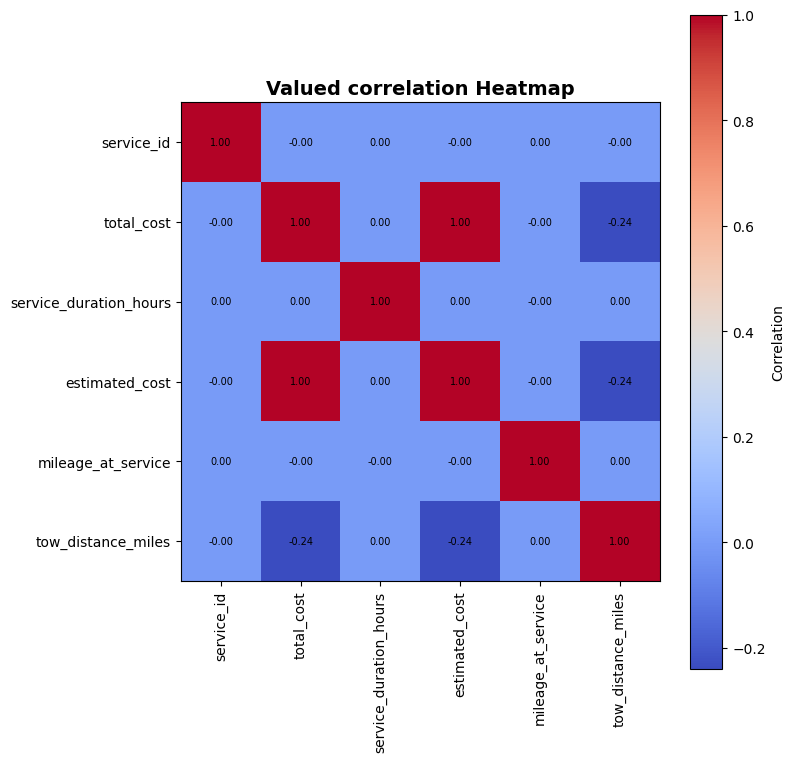

In [25]:
num_df = df.select_dtypes(include=["number"]) # Select only numeric columns
num_df = num_df.drop(["customer_feedback","technician_rating"], axis=1)
correlation = num_df.corr()

plt.figure(figsize=(8, 8))
im = plt.imshow(correlation, cmap="coolwarm", interpolation="nearest")

plt.colorbar(im, label="Correlation") # Add colorbar

# Axis labels
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.index)), correlation.index)

for i in range(len(correlation.index)): # --- Add correlation values ---
    for j in range(len(correlation.columns)):
        value = correlation.iloc[i, j]
        plt.text( j, i, f"{value:.2f}",
                 ha="center", va="center",
                 color="black", fontsize=7)

plt.title("Valued correlation Heatmap", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()


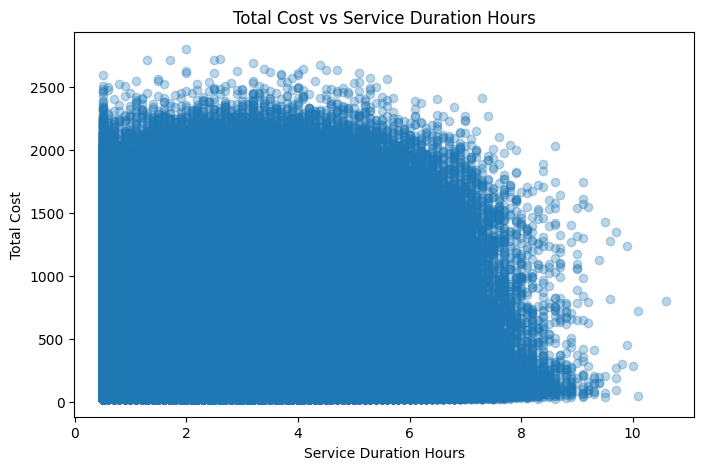

In [26]:
plt.figure(figsize=(8, 5))
plt.scatter(df["service_duration_hours"], df["total_cost"], alpha=0.3)
plt.title("Total Cost vs Service Duration Hours")
plt.xlabel("Service Duration Hours")
plt.ylabel("Total Cost")
plt.show()

> Analyzing behaviour between Total cost and Service duration hours we confirm that there is no direct relation. Need to explore correlation with other features.

#### Service type analysis

In [27]:
df.groupby("service_type")[["service_duration_hours", "total_cost"]].mean()

,service_duration_hours,total_cost
service_type,,
Battery Replacement,3.029002,200.065037
Brake Service,3.023128,299.880169
Engine Repair,3.031245,599.912074
Oil Change,3.028797,70.093764
Tire Replacement,3.025097,150.220724
Towing,3.032856,100.083687
Transmission Repair,3.032451,1199.769864


<Axes: xlabel='service_type', ylabel='total_cost'>

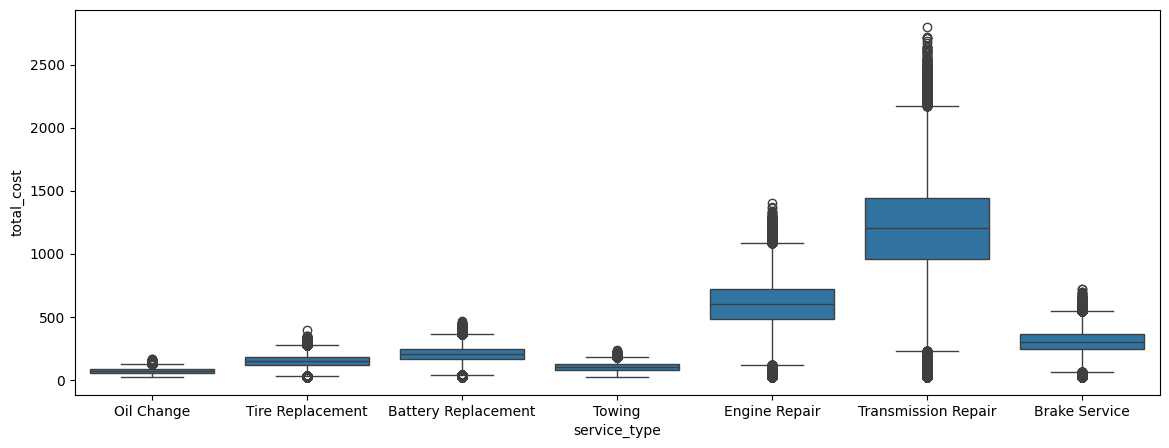

In [29]:
plt.figure(figsize=(14, 5))
sns.boxplot(x="service_type", y="total_cost", data=df)

In [30]:
for service, group in df.groupby("service_type"):
    corr = group["service_duration_hours"].corr(group["total_cost"])
    print(service, corr)

Battery Replacement -0.002534103044233529
Brake Service 0.0006509973653124825
Engine Repair 0.002015495315431197
Oil Change 0.0011374377706429514
Tire Replacement -0.0013305021115531178
Towing -0.0001261153983171364
Transmission Repair 0.0014215483888311872


> We find that correlations percentages between service timmings and total cost are under 1%